CELL 1 — MOUNT DRIVE

In [7]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CELL 2 — IMPORTS

In [8]:
import os
import re
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from glob import glob
from sklearn.metrics import confusion_matrix
from scipy.ndimage import map_coordinates, gaussian_filter



CELL 3 — PATHS

In [9]:
BASE="/content/drive/MyDrive/Project work/Dataset/lgg-mri-segmentation/lgg_structured"

MODEL_DIR="/content/drive/MyDrive/Project work/models/Segmentation"
os.makedirs(MODEL_DIR,exist_ok=True)

TRAIN_IMG=os.path.join(BASE,"train/images")
TRAIN_MASK=os.path.join(BASE,"train/masks")

VAL_IMG=os.path.join(BASE,"val/images")
VAL_MASK=os.path.join(BASE,"val/masks")

TEST_IMG=os.path.join(BASE,"test/images")
TEST_MASK=os.path.join(BASE,"test/masks")

CKPT="/content/best.h5"
SAVE_PATH=os.path.join(MODEL_DIR,"attention_resunet___.keras")

for name,p in [
("train_img",TRAIN_IMG),
("train_mask",TRAIN_MASK),
("val_img",VAL_IMG),
("val_mask",VAL_MASK),
("test_img",TEST_IMG),
("test_mask",TEST_MASK)
]:
    print(name,os.path.exists(p))

train_img True
train_mask True
val_img True
val_mask True
test_img True
test_mask True


CELL 4 — CONFIG

In [10]:
IMG_SIZE=256
BATCH_SIZE=8
EPOCHS=80
SEED=42
AUTOTUNE=tf.data.AUTOTUNE

CELL 5 — DATA LOADING

In [11]:
def nsort(p):
    return [int(n) for n in re.findall(r"\d+",os.path.basename(p))]

train_imgs=sorted(glob(os.path.join(TRAIN_IMG,"*")),key=nsort)
train_masks=sorted(glob(os.path.join(TRAIN_MASK,"*")),key=nsort)

val_imgs=sorted(glob(os.path.join(VAL_IMG,"*")),key=nsort)
val_masks=sorted(glob(os.path.join(VAL_MASK,"*")),key=nsort)

test_imgs=sorted(glob(os.path.join(TEST_IMG,"*")),key=nsort)
test_masks=sorted(glob(os.path.join(TEST_MASK,"*")),key=nsort)

print("Train:",len(train_imgs))
print("Val:",len(val_imgs))
print("Test:",len(test_imgs))

assert len(train_imgs)==len(train_masks)
assert len(val_imgs)==len(val_masks)

Train: 3133
Val: 409
Test: 387


CELL 6 — FILTER EMPTY MASKS

In [12]:
def has_tumor(mask_path):

    m=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

    return m is not None and m.max()>0


train_pairs=[(i,m) for i,m in zip(train_imgs,train_masks) if has_tumor(m)]
val_pairs=[(i,m) for i,m in zip(val_imgs,val_masks) if has_tumor(m)]

train_imgs_f,train_masks_f=map(list,zip(*train_pairs))
val_imgs_f,val_masks_f=map(list,zip(*val_pairs))

print("Filtered Train:",len(train_imgs_f))
print("Filtered Val:",len(val_imgs_f))

Filtered Train: 1065
Filtered Val: 151


CELL 7 — PREPROCESSING

In [13]:
def load_image(path):

    img=cv2.imread(path.numpy().decode(),cv2.IMREAD_GRAYSCALE)

    if img is None:
        return np.zeros((IMG_SIZE,IMG_SIZE,1),np.float32)

    img=cv2.resize(img,(IMG_SIZE,IMG_SIZE)).astype(np.float32)/255.0

    clahe=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
    img=clahe.apply((img*255).astype(np.uint8))

    img=img.astype(np.float32)/255.0

    return np.expand_dims(img,-1)


def load_mask(path):

    m=cv2.imread(path.numpy().decode(),cv2.IMREAD_GRAYSCALE)

    if m is None:
        return np.zeros((IMG_SIZE,IMG_SIZE,1),np.float32)

    m=cv2.resize(m,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_NEAREST)
    m=(m>127).astype(np.float32)

    return np.expand_dims(m,-1)


def parse(img_path,mask_path):

    img=tf.py_function(load_image,[img_path],tf.float32)
    mask=tf.py_function(load_mask,[mask_path],tf.float32)

    img.set_shape([IMG_SIZE,IMG_SIZE,1])
    mask.set_shape([IMG_SIZE,IMG_SIZE,1])

    return img,mask

CELL 8 — AUGMENTATION

In [24]:
def augment(img,mask):

    if tf.random.uniform(())>0.5:
        img=tf.image.flip_left_right(img)
        mask=tf.image.flip_left_right(mask)

    if tf.random.uniform(())>0.5:
        img=tf.image.flip_up_down(img)
        mask=tf.image.flip_up_down(mask)

    k=tf.random.uniform([],0,4,dtype=tf.int32)
    img=tf.image.rot90(img,k)
    mask=tf.image.rot90(mask,k)

    mask=tf.cast(mask>0.5,tf.float32)

    return img,mask


def to_dict(img,mask):
    return img, mask

CELL 9 — DATA PIPELINE

In [25]:
train_ds=(
tf.data.Dataset.from_tensor_slices((train_imgs_f,train_masks_f))
.shuffle(len(train_imgs_f),seed=SEED)
.map(parse,num_parallel_calls=AUTOTUNE)
.map(augment,num_parallel_calls=AUTOTUNE)
.map(to_dict,num_parallel_calls=AUTOTUNE)
.batch(BATCH_SIZE)
.prefetch(AUTOTUNE)
)

val_ds=(
tf.data.Dataset.from_tensor_slices((val_imgs_f,val_masks_f))
.map(parse,num_parallel_calls=AUTOTUNE)
.map(to_dict,num_parallel_calls=AUTOTUNE)
.batch(BATCH_SIZE)
.prefetch(AUTOTUNE)
)

print("datasets ready")

datasets ready


CELL 10 — LOSS & METRICS

In [26]:
def dice_coef(y_true,y_pred,smooth=1):

    y_true=tf.reshape(tf.cast(y_true,tf.float32),[-1])
    y_pred=tf.reshape(tf.cast(y_pred,tf.float32),[-1])

    inter=tf.reduce_sum(y_true*y_pred)

    return (2*inter+smooth)/(tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)+smooth)


def combined_loss(y_true,y_pred):

    bce=tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true,y_pred))

    inter=tf.reduce_sum(y_true*y_pred)
    dice=(2*inter+1)/(tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)+1)

    return bce+(1-dice)

CELL 11 — MODEL BLOCKS

In [27]:
def conv_block(x,f):

    x=tf.keras.layers.Conv2D(f,3,padding="same")(x)
    x=tf.keras.layers.BatchNormalization()(x)
    x=tf.keras.layers.Activation("relu")(x)

    x=tf.keras.layers.Conv2D(f,3,padding="same")(x)
    x=tf.keras.layers.BatchNormalization()(x)
    x=tf.keras.layers.Activation("relu")(x)

    return x


def res_block(inp,f):

    x=conv_block(inp,f)

    r=tf.keras.layers.Conv2D(f,1,padding="same")(inp)

    return tf.keras.layers.Add()([x,r])

CELL 12 — BUILD MODEL

In [28]:
def build_model(size):

    inp=tf.keras.Input((size,size,1))

    e1=res_block(inp,64)
    p1=tf.keras.layers.MaxPooling2D()(e1)

    e2=res_block(p1,128)
    p2=tf.keras.layers.MaxPooling2D()(e2)

    e3=res_block(p2,256)
    p3=tf.keras.layers.MaxPooling2D()(e3)

    b=conv_block(p3,512)

    u1=tf.keras.layers.Conv2DTranspose(256,2,strides=2,padding="same")(b)
    d1=conv_block(tf.keras.layers.Concatenate()([u1,e3]),256)

    u2=tf.keras.layers.Conv2DTranspose(128,2,strides=2,padding="same")(d1)
    d2=conv_block(tf.keras.layers.Concatenate()([u2,e2]),128)

    u3=tf.keras.layers.Conv2DTranspose(64,2,strides=2,padding="same")(d2)
    d3=conv_block(tf.keras.layers.Concatenate()([u3,e1]),64)

    out=tf.keras.layers.Conv2D(1,1,activation="sigmoid")(d3)

    return tf.keras.Model(inp,out)

model=build_model(IMG_SIZE)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 256, 256,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │     36,928 │ activation_14[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │        128 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 256,  │          0 │ activation_15[0]… │
│                     │ 64)               │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 128, 128,  │          0 │ add_3[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │    147,584 │ activation_16[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 128, 128,  │      8,320 │ max_pooling2d_3[

 Total params: 7,748,929 (29.56 MB)

 Trainable params: 7,743,297 (29.54 MB)

 Non-trainable params: 5,632 (22.00 KB)

CELL 13 — COMPILE

In [29]:
model.compile(
optimizer=tf.keras.optimizers.Adam(1e-4),
loss=combined_loss,
metrics=[dice_coef]
)

CELL 14 — CALLBACKS

In [30]:
callbacks=[

tf.keras.callbacks.ModelCheckpoint(
CKPT,
monitor="val_dice_coef",
mode="max",
save_best_only=True
),

tf.keras.callbacks.EarlyStopping(
monitor="val_dice_coef",
mode="max",
patience=15,
restore_best_weights=True
)

]

CELL 15 — TRAIN

In [31]:
history=model.fit(
train_ds,
validation_data=val_ds,
epochs=EPOCHS,
callbacks=callbacks
)

Epoch 1/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - dice_coef: 0.1116 - loss: 1.3436

134/134 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - dice_coef: 0.1119 - loss: 1.3422 - val_dice_coef: 0.0566 - val_loss: 1.4480
Epoch 2/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - dice_coef: 0.2461 - loss: 0.9074

134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - dice_coef: 0.2462 - loss: 0.9072 - val_dice_coef: 0.0585 - val_loss: 1.1966
Epoch 3/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - dice_coef: 0.2917 - loss: 0.8378

134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - dice_coef: 0.2919 - loss: 0.8375 - val_dice_coef: 0.1054 - val_loss: 1.1229
Epoch 4/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - dice_coef: 0.3629 - loss: 0.7453

134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - dice_coef: 0.3630 - loss: 0.7451 - val_dice_coef: 0.2254 - val_loss: 1.0488
Epoch 5/80
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - dice_coef: 0.4199 - loss: 0.6717

...

134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - dice_coef: 0.8176 - loss: 0.2167 - val_dice_coef: 0.5986 - val_loss: 0.4620
Epoch 29/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - dice_coef: 0.8194 - loss: 0.2150 - val_dice_coef: 0.4816 - val_loss: 0.6003
Epoch 30/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - dice_coef: 0.8166 - loss: 0.2194 - val_dice_coef: 0.5733 - val_loss: 0.4943
Epoch 31/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8322 - loss: 0.2018 - val_dice_coef: 0.3904 - val_loss: 0.9507
Epoch 32/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - dice_coef: 0.8106 - loss: 0.2294 - val_dice_coef: 0.5246 - val_loss: 0.5723
Epoch 33/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8281 - loss: 0.2066 - val_dice_coef: 0.5205 - val_loss: 0.5937
Epoch 34/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - dice_coef: 0.8231 - loss: 0.2125

134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - dice_coef: 0.8231 - loss: 0.2124 - val_dice_coef: 0.6117 - val_loss: 0.4626
Epoch 35/80
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - dice_coef: 0.8372 - loss: 0.1952

134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - dice_coef: 0.8372 - loss: 0.1952 - val_dice_coef: 0.6185 - val_loss: 0.4457
Epoch 36/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8336 - loss: 0.2008 - val_dice_coef: 0.5498 - val_loss: 0.5263
Epoch 37/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8225 - loss: 0.2138 - val_dice_coef: 0.5141 - val_loss: 0.5746
Epoch 38/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - dice_coef: 0.8267 - loss: 0.2103 - val_dice_coef: 0.5906 - val_loss: 0.5057
Epoch 39/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - dice_coef: 0.8422 - loss: 0.1887

134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - dice_coef: 0.8423 - loss: 0.1887 - val_dice_coef: 0.6449 - val_loss: 0.4159
Epoch 40/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - dice_coef: 0.8376 - loss: 0.1955 - val_dice_coef: 0.5717 - val_loss: 0.5014
Epoch 41/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - dice_coef: 0.8523 - loss: 0.1776 - val_dice_coef: 0.5189 - val_loss: 0.5795
Epoch 42/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - dice_coef: 0.8405 - loss: 0.1899 - val_dice_coef: 0.5881 - val_loss: 0.5131
Epoch 43/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8484 - loss: 0.1814 - val_dice_coef: 0.5378 - val_loss: 0.6472
Epoch 44/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8596 - loss: 0.1692 - val_dice_coef: 0.6338 - val_loss: 0.4373
Epoch 45/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8613 - loss: 0.1683 - val_dice_coef: 0.5794 - val_loss: 0.5179
Epoch 46/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8575 - loss

134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - dice_coef: 0.8582 - loss: 0.1702 - val_dice_coef: 0.6660 - val_loss: 0.3897
Epoch 55/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - dice_coef: 0.8765 - loss: 0.1491 - val_dice_coef: 0.6114 - val_loss: 0.4566
Epoch 56/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8507 - loss: 0.1797 - val_dice_coef: 0.5998 - val_loss: 0.4686
Epoch 57/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8246 - loss: 0.2120 - val_dice_coef: 0.6207 - val_loss: 0.4493
Epoch 58/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8651 - loss: 0.1639 - val_dice_coef: 0.6180 - val_loss: 0.4484
Epoch 59/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8790 - loss: 0.1466 - val_dice_coef: 0.5830 - val_loss: 0.4977
Epoch 60/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8748 - loss: 0.1500 - val_dice_coef: 0.6398 - val_loss: 0.4193
Epoch 61/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - dice_coef: 0.8777 - loss

CELL 16 — GRAPH

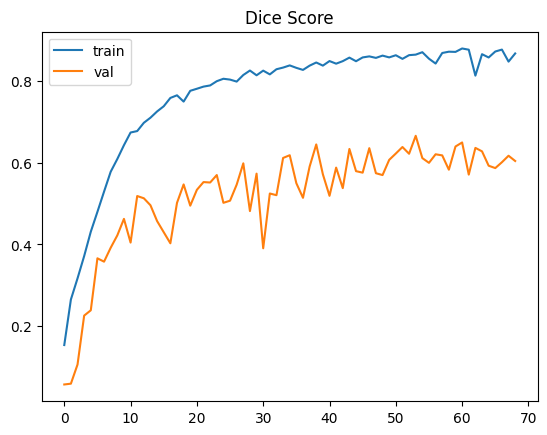

In [32]:
plt.plot(history.history["dice_coef"])
plt.plot(history.history["val_dice_coef"])
plt.title("Dice Score")
plt.legend(["train","val"])
plt.show()

CELL 17 — TEST DATASET

In [33]:
test_ds=(
tf.data.Dataset.from_tensor_slices((test_imgs,test_masks))
.map(parse)
.batch(BATCH_SIZE)
)

CELL 18 — EVALUATION

In [34]:
results=model.evaluate(test_ds)

print("Test Dice:",results[1])

49/49 ━━━━━━━━━━━━━━━━━━━━ 442s 9s/step - dice_coef: 0.3135 - loss: 0.7115
Test Dice: 0.3902296721935272


CELL 19 — SAVE MODEL

In [35]:
model.save(SAVE_PATH)

print("Model saved:",SAVE_PATH)

Model saved: /content/drive/MyDrive/Project work/models/Segmentation/attention_resunet___.keras
